In [1]:
import pandas as pd

df = pd.read_csv("dataset/creditcard_2023.csv")  # check file
# V1-V28: Anonymized features representing various transaction attributes (e.g., time, location, etc.)
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [2]:
# Define features (X) and target (y)
# Drop 'id' (identifier) and 'Class' (target) for features
feature_cols = [c for c in df.columns if c not in ['id', 'Class']]
X = df[feature_cols]
y = df['Class']

# Split into train (80%) and test (20%)
# stratify=y keeps the same fraud/non-fraud ratio in both sets (important for imbalanced data)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
print(f"Train fraud rate: {y_train.mean():.4f}, Test fraud rate: {y_test.mean():.4f}")

Train: 454904 samples, Test: 113726 samples
Train fraud rate: 0.5000, Test fraud rate: 0.5000


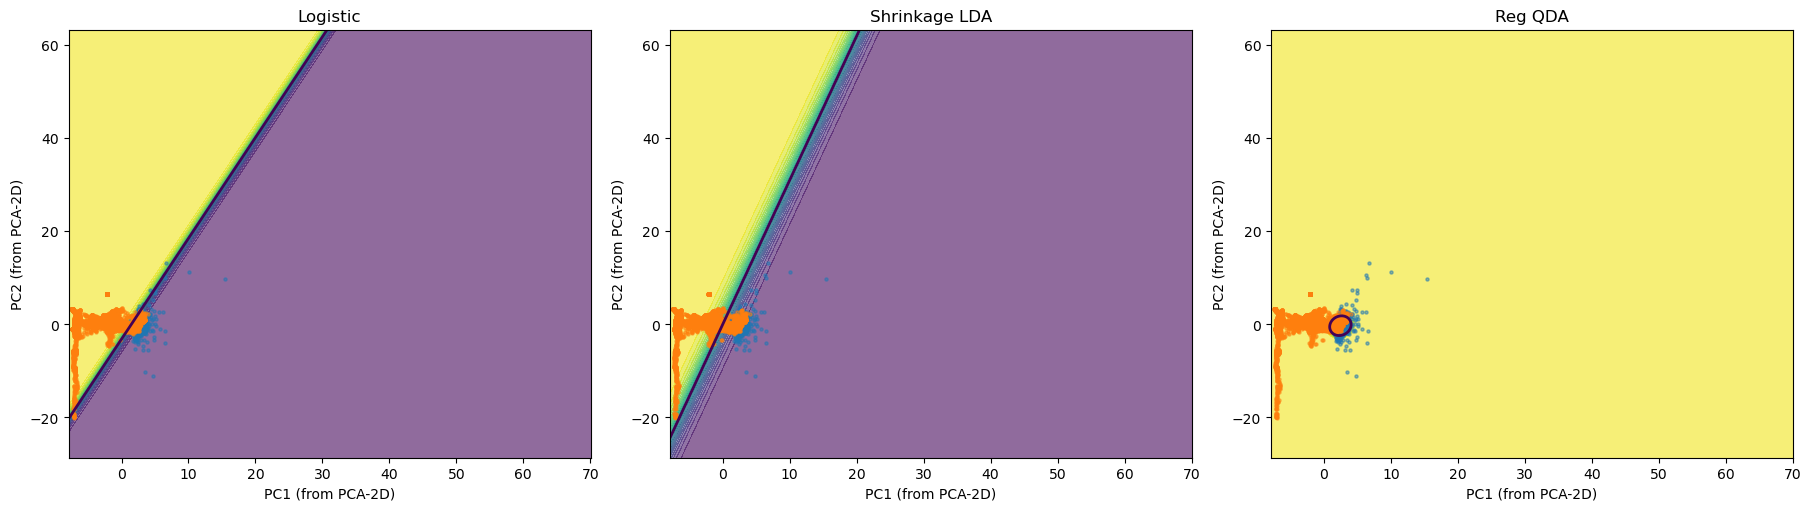

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# 1) 2D projection transformer (fit on train only!)
proj = Pipeline([
    ("scaler", StandardScaler()),
    ("pca2", PCA(n_components=2, random_state=42))
])

X2_train = proj.fit_transform(X_train)
X2_test  = proj.transform(X_test)

# 2) models in 2D
models = {
    "Logistic": LogisticRegression(max_iter=2000),
    "Shrinkage LDA": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
    "Reg QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),  # 예시값 (grid로 튜닝 가능)
}

def plot_boundary(ax, model, X2, y, title, grid_step=0.02, max_points=20000):
    # 너무 많은 점이면 다운샘플
    if len(X2) > max_points:
        idx = np.random.RandomState(42).choice(len(X2), size=max_points, replace=False)
        Xp, yp = X2[idx], y.iloc[idx] if hasattr(y, "iloc") else y[idx]
    else:
        Xp, yp = X2, y

    # mesh grid
    x_min, x_max = X2[:,0].min() - 0.5, X2[:,0].max() + 0.5
    y_min, y_max = X2[:,1].min() - 0.5, X2[:,1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # fit in 2D, then predict proba on grid
    model.fit(X2, y)
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    # background probability + decision boundary at 0.5
    cs = ax.contourf(xx, yy, proba, levels=30, alpha=0.6)
    ax.contour(xx, yy, proba, levels=[0.5], linewidths=2)

    # points
    ax.scatter(Xp[yp==0, 0], Xp[yp==0, 1], s=5, alpha=0.5)
    ax.scatter(Xp[yp==1, 0], Xp[yp==1, 1], s=5, alpha=0.5)

    ax.set_title(title)
    ax.set_xlabel("PC1 (from PCA-2D)")
    ax.set_ylabel("PC2 (from PCA-2D)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (name, model) in zip(axes, models.items()):
    plot_boundary(ax, model, X2_train, y_train, title=name)

plt.show()